In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [56]:
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces()
x = data.data
y = data.target

X.shape
#40 people , each with 10 face image so total 400 img. 
#image size= 64x64 pixels thus 4096 features that means one image is represend by 4096 features

(400, 4096)

In [13]:
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("people:", len(np.unique(y)))


Samples: 400
Features: 4096
people: 40


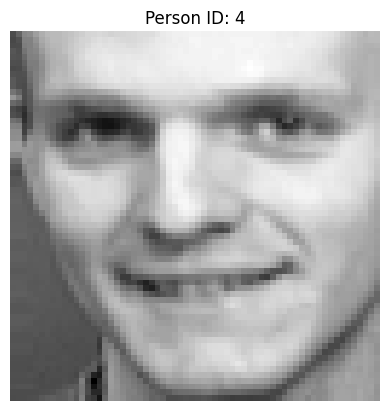

In [ ]:
idx =45
plt.imshow(X[idx].reshape(64, 64), cmap='gray')
plt.title(f"Person ID: {y[idx]}")
plt.axis('off')
plt.show()


In [103]:
df = pd.DataFrame(X)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.665289,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.136364,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.074380,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.652893,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.190083,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554


In [15]:
df.isnull().sum().max()


np.int64(0)

In [16]:
df['person_id'].value_counts().head()


person_id
0    10
1    10
2    10
3    10
4    10
Name: count, dtype: int64

In [18]:
#pixel value range
X.min(), X.max()


(np.float32(0.0), np.float32(1.0))

In [19]:
df.drop(columns='person_id').describe()

,0,1,2,3,4,5,6,7,8,9,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.400134,0.434236,0.476281,0.518481,0.554845,0.588729,0.621426,0.647510,0.664814,0.676591,...,0.363079,0.367221,0.363027,0.355506,0.340196,0.338657,0.335909,0.321415,0.313647,0.310455
std,0.180695,0.189504,0.194742,0.193313,0.188593,0.178481,0.167109,0.155024,0.147616,0.143583,...,0.164952,0.181861,0.181611,0.188709,0.186088,0.189256,0.195280,0.187842,0.183616,0.180635
min,0.086777,0.066116,0.090909,0.041322,0.107438,0.107438,0.115702,0.115702,0.119835,0.140496,...,0.049587,0.037190,0.053719,0.049587,0.033058,0.012397,0.049587,0.057851,0.061983,0.033058
25%,0.243802,0.267562,0.314050,0.383264,0.446281,0.515496,0.544421,0.581612,0.599174,0.611570,...,0.227273,0.214876,0.219008,0.197314,0.177686,0.177686,0.173554,0.173554,0.173554,0.172521
50%,0.392562,0.458678,0.512397,0.545455,0.584711,0.615702,0.652893,0.669421,0.683884,0.702479,...,0.367769,0.367769,0.342975,0.334711,0.320248,0.314050,0.299587,0.289256,0.270661,0.272727
75%,0.528926,0.575413,0.636364,0.666322,0.702479,0.714876,0.735537,0.757231,0.772727,0.780992,...,0.484504,0.496901,0.500000,0.500000,0.479339,0.462810,0.462810,0.446281,0.414256,0.417355
max,0.805785,0.822314,0.871901,0.892562,0.871901,0.871901,0.871901,0.871901,0.871901,0.871901,...,0.793388,0.904959,0.888430,0.896694,0.826446,0.863636,0.921488,0.929752,0.884298,0.822314


In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=1
)


In [105]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [106]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred_no_pca = rf.predict(X_test_scaled)


In [107]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_no_pca = r2_score(y_test, y_pred_no_pca)
mse_no_pca = mean_squared_error(y_test, y_pred_no_pca)
mae_no_pca = mean_absolute_error(y_test, y_pred_no_pca)
rmse_no_pca = np.sqrt(mse_no_pca)

print("WITHOUT PCA")
print("R2   :", r2_no_pca)
print("MSE  :", mse_no_pca)
print("MAE  :", mae_no_pca)
print("RMSE :", rmse_no_pca)


WITHOUT PCA
R2   : 0.5691691866685344
MSE  : 58.94950311111111
MAE  : 6.110400000000001
RMSE : 7.677857976747884


In [108]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(
    n_neighbors=5,
    weights='distance',
    metric='manhattan'
)

knn.fit(X_train_scaled, y_train)
y_pred_no_pca = knn.predict(X_test_scaled)


In [109]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

r2_no_pca = r2_score(y_test, y_pred_no_pca)
mse_no_pca = mean_squared_error(y_test, y_pred_no_pca)
mae_no_pca = mean_absolute_error(y_test, y_pred_no_pca)
rmse_no_pca = np.sqrt(mse_no_pca)

print("KNN WITHOUT PCA")
print("R2   :", r2_no_pca)
print("MSE  :", mse_no_pca)
print("MAE  :", mae_no_pca)
print("RMSE :", rmse_no_pca)


KNN WITHOUT PCA
R2   : 0.724245176003941
MSE  : 37.73084318032076
MAE  : 3.8466903281960656
RMSE : 6.142543706016324


In [113]:
from sklearn.decomposition import PCA

pca = PCA(n_components=55, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


In [122]:
knn_pca = KNeighborsRegressor(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)


In [123]:
r2_pca = r2_score(y_test, y_pred_pca)
mse_pca = mean_squared_error(y_test, y_pred_pca)
mae_pca = mean_absolute_error(y_test, y_pred_pca)
rmse_pca = np.sqrt(mse_pca)

print("KNN WITH PCA")
print("R2   :", r2_pca)
print("MSE  :", mse_pca)
print("MAE  :", mae_pca)
print("RMSE :", rmse_pca)


KNN WITH PCA
R2   : 0.8228973236393691
MSE  : 24.232516449734234
MAE  : 2.8197587040759937
RMSE : 4.922653395246738
